In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

# The second run for test
THe first run was using TATT model for 2pt.
Now we use NLA model consistently to see the improvement in the IA parameter constraint.

In [3]:
def get(fname):
    chain, params, labels = utils.read_des_chain(fname, take=['om', 's8', 'sig8', 'a1', 'a2', 'alpha1', 'alpha2', 'map3-chi2'])
    samples = utils.to_mcsamples(chain, params, labels)
    utils.wplot(chain, params, labels)
    return samples

['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', '2pt-chi2', 'map3-chi2', 'prior', 'like', 'post', 'weight']
Removed no burn in


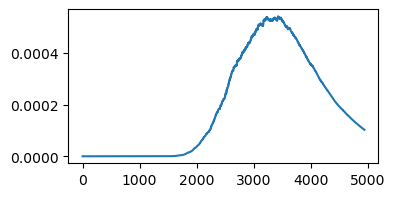

['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', '2pt-chi2', 'map3-chi2', 'prior', 'like', 'post', 'weight']
Removed no burn in


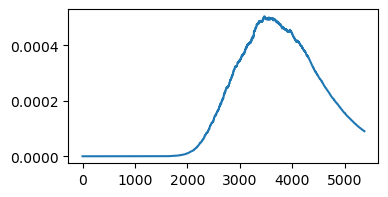

['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', '2pt-chi2', 'prior', 'like', 'post', 'weight']
Removed no burn in


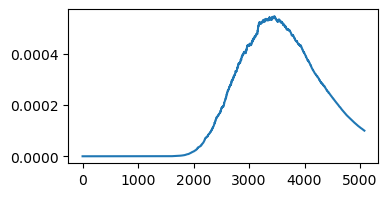

In [11]:
samples_2pt_map3_auto_334_344 = get('../output/test-desy3c-run/des-y3-2pt-map3-auto-334-344.txt')
samples_emu_2pt_map3_all = get('../output/test-desy3c-emu-run/des-y3-2pt-map3-all.txt')
samples_2pt = get('../output/test-desy3c-run/des-y3-2pt.txt')

<Figure size 800x800 with 0 Axes>

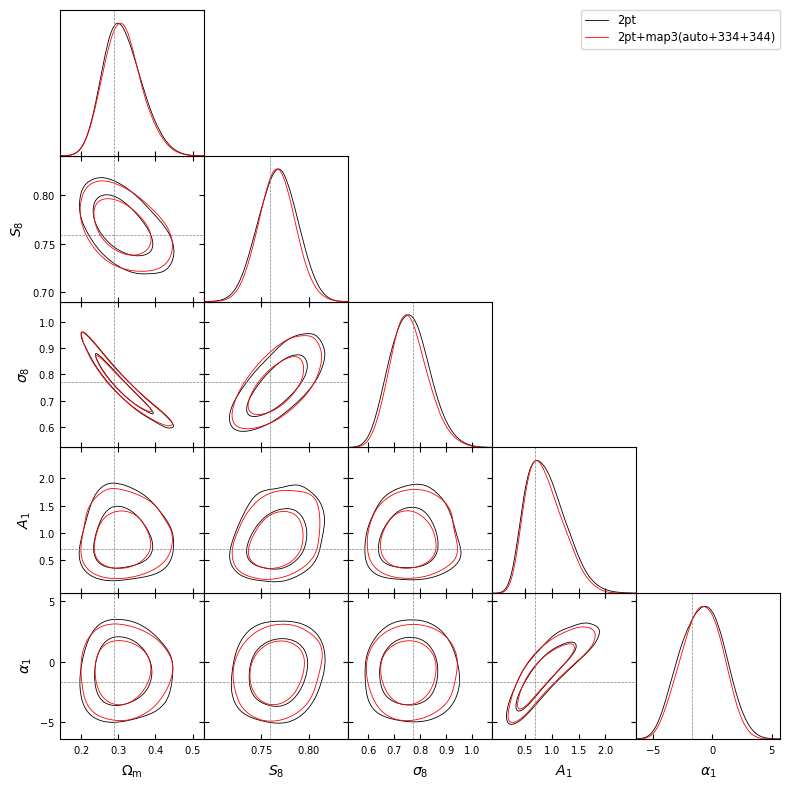

In [7]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto+334+344)'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()

In [8]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_2pt_map3_auto_334_344]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [9]:
fom

array([1118.71093497, 1158.26830876])

In [10]:
improve

array([1.        , 1.03535978])

<Figure size 800x800 with 0 Axes>

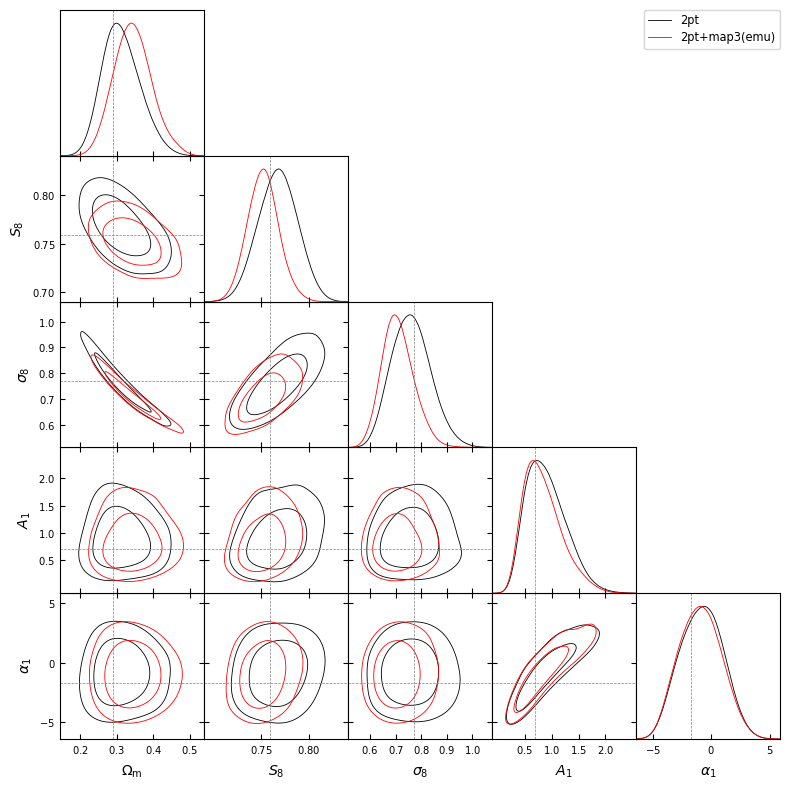

In [19]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([samples_2pt, samples_emu_2pt_map3_all], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(emu)'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
#plt.show()
plt.savefig("2pt_map3_emu_all_combinations.pdf")

In [16]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_emu_2pt_map3_all]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [17]:
fom

array([1118.71093497, 1280.84455765])

In [18]:
improve

array([1.        , 1.14492897])

# signal

In [9]:
import threepoint

2.671916735624206


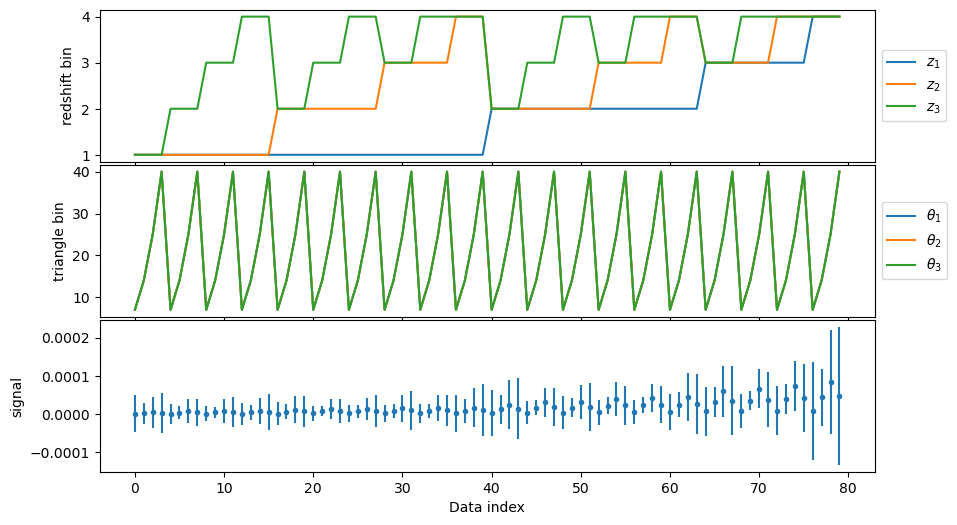

In [10]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-cosmoDESY3.fits')
print(thpt.get_snr())
fig = thpt.plot(yscale='linear', nt=4)

## Forecast

In [123]:
names = samples_2pt_map3_auto_334_344.paramNames.getRunningNames()
s = samples_2pt_map3_auto_334_344.samples
w = samples_2pt_map3_auto_334_344.weights

s8 = s[:, names.index('s8')]
om = s[:, names.index('om')]
sg8= s[:, names.index('sig8')]
map3chi2 = s[:, names.index('map3-chi2')]

temp = 2**2 /0.842
w2= w*np.exp(-map3chi2/2.0*temp + map3chi2/2.0)

samples_2pt_map3_auto_334_344_v2 = MCSamples(samples=[s8, om, sg8], weights=w2, names=['s8', 'om', 'sig8'], labels=['S_8', '\Omega_{\rm m}', '\sigma_8'])

Removed no burn in


<Figure size 600x600 with 0 Axes>

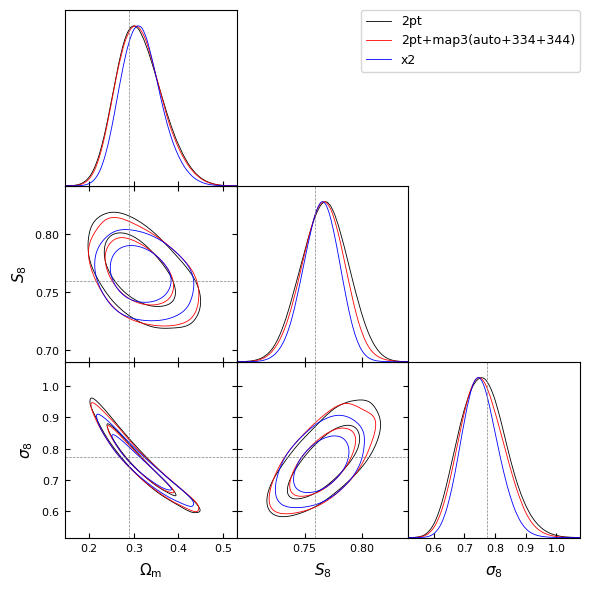

<Figure size 600x600 with 0 Axes>

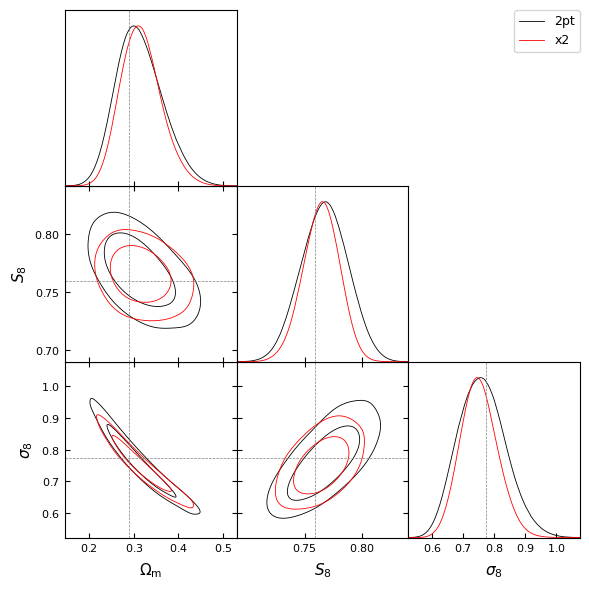

In [124]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344, samples_2pt_map3_auto_334_344_v2], 
    ['om', 's8', 'sig8'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto+334+344)', 'x2'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()

g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344_v2], 
    ['om', 's8', 'sig8'], filled=False, \
    legend_labels=['2pt', 'x2'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()

In [120]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_2pt_map3_auto_334_344, samples_2pt_map3_auto_334_344_v2]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [121]:
fom

array([1118.71093497, 1171.50801544, 1438.26854423])

In [122]:
improve

array([1.        , 1.04719457, 1.28564806])

In [78]:
import threepoint

2.770700842462768


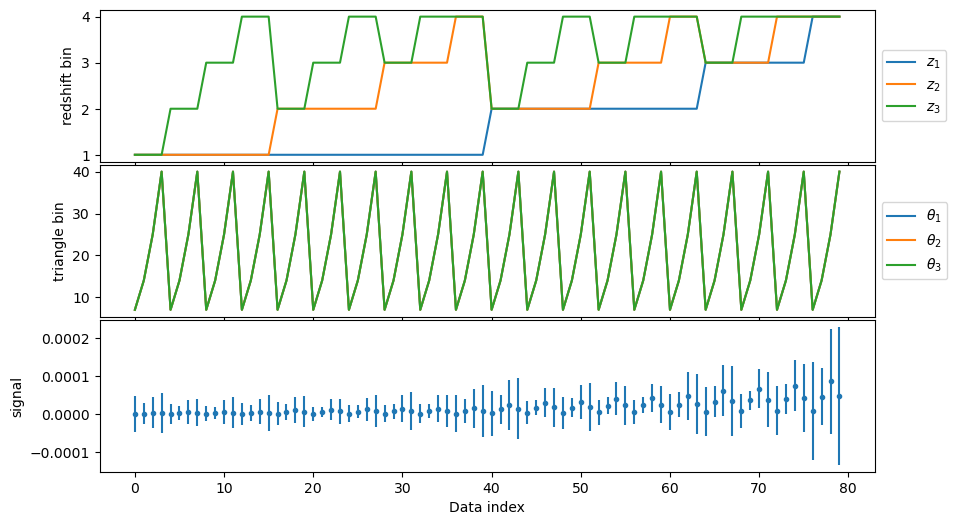

In [79]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-cosmoDESY3.fits')
print(thpt.get_snr())
fig = thpt.plot(yscale='linear', nt=4)

In [80]:
thpt.reduce_by_z_bin_selection(['auto', '3,3,4', '3,4,4'])

2.0929819631555975


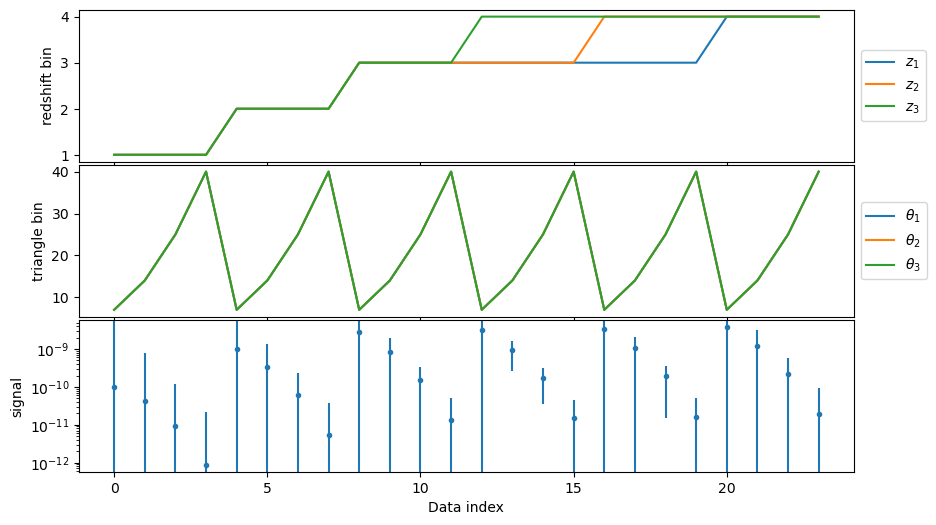

In [81]:
print(thpt.get_snr())
fig = thpt.plot(yscale='log')

In [82]:
np.diag(thpt.get_covariance())**0.5

array([2.08002748e-08, 7.35694326e-10, 1.07848784e-10, 2.09868634e-11,
       2.54475210e-08, 1.02369879e-09, 1.70678387e-10, 3.22581253e-11,
       2.75908555e-08, 1.06080522e-09, 1.76563603e-10, 3.66078845e-11,
       1.91759036e-08, 6.74676250e-10, 1.35824536e-10, 2.88920741e-11,
       2.76273582e-08, 1.05280716e-09, 1.76157787e-10, 3.58610264e-11,
       5.52456457e-08, 2.01721193e-09, 3.62431229e-10, 7.30469459e-11])

In [83]:
thpt.get_t_bin()[0,:]

array([ 7., 14., 25., 40.,  7., 14., 25., 40.,  7., 14., 25., 40.,  7.,
       14., 25., 40.,  7., 14., 25., 40.,  7., 14., 25., 40.])

In [84]:
1e-8/25

4e-10

In [85]:
0.95**(1.0/4.0)

0.9872585449014338

In [86]:
0.9872585449014338**8

0.9025000000000002

6.729734137316413


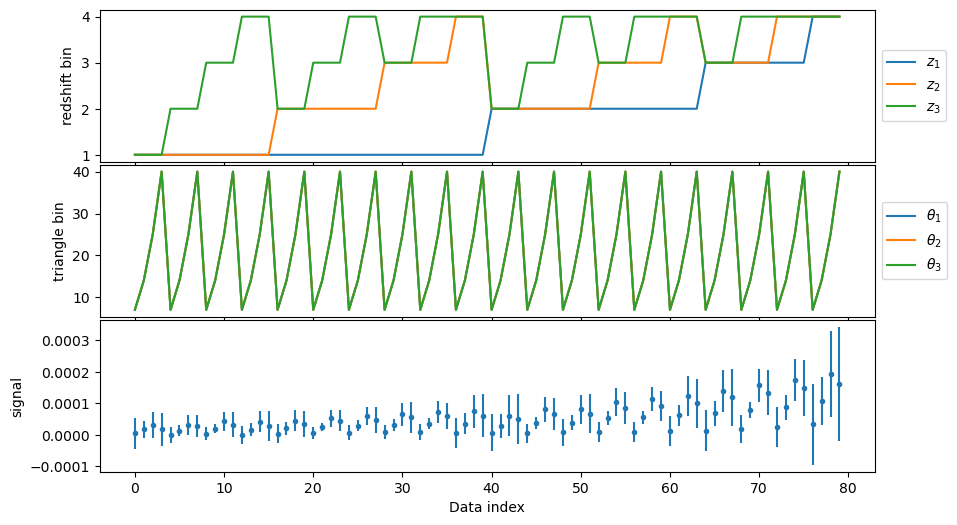

In [87]:
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/nz/map3_dv_COSMOGRID_19Apr24.fits')
# thpt2 = threepoint.ThreePointDataClass.from_fits('../data/nz/map3_dv_NOISY_COSMOGRID_11Apr24_ALL_ZCORRELATIONS_320SIMS.fits')
print(thpt2.get_snr())
fig = thpt2.plot(yscale='linear', nt=4)

In [88]:
((400 - 80 - 2)/(400-1))**0.5

0.8927443537782849

In [89]:
thpt1 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-cosmoDESY3.fits')
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/nz/map3_dv_COSMOGRID_19Apr24.fits')

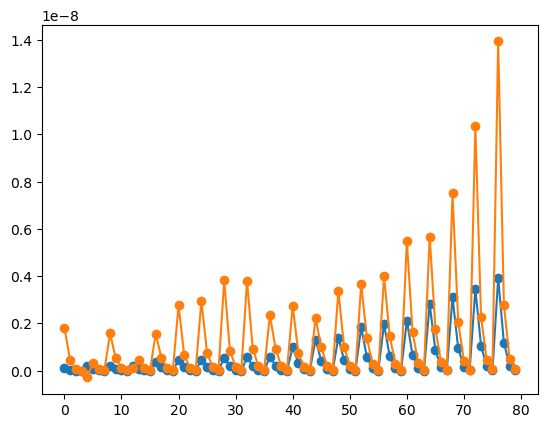

In [90]:
plt.plot(thpt1.get_signal(), marker='o')
plt.plot(thpt2.get_signal(), marker='o')
plt.show()

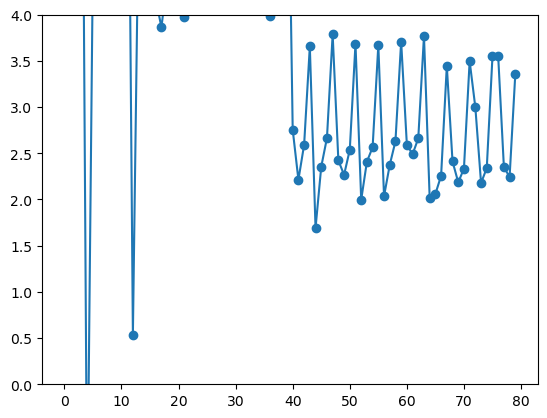

In [91]:
plt.plot(thpt2.get_signal()/thpt1.get_signal(), marker='o')
plt.ylim(0.0, 4.0)
plt.show()